# Actividad 1 — Predicción de churn con Regresión Logística

**Contexto.** Una  empresa  de  telecomunicaciones  desea  predecir  qué  clientes  tienen  mayor  probabilidad  de fugarse(*churn*), para diseñar campañas de retención. Se cuenta con un dataset de clientes, sus características de uso y una  etiqueta  binaria  que  indica  si  el  cliente  se  fue  (churn  =  1)  o  se  mantuvo  (churn  =  0).El  objetivo  de  esta actividad es construir y evaluar modelos de regresión logística, comparando:

1. Un modelo con *features* “básicas” (preprocesadas).
2. Un modelo con *transformaciones polinomiales* sobre las featuresnuméricas.
3. Modelos con *penalización* (regularización) para controlar complejidad.

La evaluación debe realizarse mediante validación cruzada *k-fold*, utilizando *matriz de confusión*, curva *ROC* y curva *Precision–Recall*, en línea con lo visto en la clase.


## 🔎 Descripción de Variables — Dataset de Churn

El dataset contiene información demográfica, contractual y de uso de servicios de clientes de telecomunicaciones.  
La variable objetivo es **Churn**, que indica si el cliente se dio de baja del servicio.

---

### 📋 Diccionario de Variables

| Variable | Tipo | Descripción |
|----------|------|-------------|
| **customerID** | Identificador | Código único del cliente | 
| **gender** | Categórica binaria | Sexo del cliente | 
| **SeniorCitizen** | Binaria (0/1) | Indica si el cliente es adulto mayor |
| **Partner** | Binaria | Indica si tiene pareja |
| **Dependents** | Binaria | Si tiene dependientes |
| **tenure** | Numérica continua | Meses que lleva como cliente |
| **PhoneService** | Binaria | Servicio telefónico contratado |
| **MultipleLines** | Categórica | Si tiene múltiples líneas telefónicas |
| **InternetService** | Categórica | Tipo de internet (DSL, Fiber optic, None) |
| **OnlineSecurity** | Categórica | Servicio de seguridad online |
| **OnlineBackup** | Categórica | Servicio de respaldo en la nube |
| **DeviceProtection** | Categórica | Protección de dispositivos |
| **TechSupport** | Categórica | Soporte técnico contratado |
| **StreamingTV** | Categórica | Servicio de televisión en streaming |
| **StreamingMovies** | Categórica | Servicio de películas en streaming |
| **Contract** | Categórica | Tipo de contrato (mensual, anual, 2 años) |
| **PaperlessBilling** | Binaria | Facturación digital |
| **PaymentMethod** | Categórica | Método de pago |
| **MonthlyCharges** | Numérica | Cargo mensual del servicio |
| **TotalCharges** | Numérica | Total histórico pagado |
| **Churn** | Variable objetivo | YES = cliente se fue,NO = cliente se quedó |



In [63]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
    make_scorer,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    average_precision_score
 )
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [65]:
df_raw = pd.read_csv("data-churn.csv")
df_raw.shape, df_raw.columns.tolist()[:21]

((7043, 21),
 ['customerID',
  'gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'tenure',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'MonthlyCharges',
  'TotalCharges',
  'Churn'])

## Paso 0 — Dataset y variables

Se trabaja con el archivo `data-churn.csv`. La variable objetivo es `Churn`, que representa si el cliente se fugó (1) o se mantuvo (0).

A continuación se revisan variables, tipos y se definen los grupos **numéricos** y **categóricos** que entrarán al preprocesamiento.

In [66]:
df = df_raw.copy()
target_col = "Churn"

# ================================
# 1️⃣ LIMPIEZA INICIAL
# ================================

# Eliminar identificadores
df = df.drop(columns=["customerID"], errors="ignore")

# Variable objetivo a binaria
df[target_col] = df[target_col].map({"Yes": 1, "No": 0})

# ================================
# 2️⃣ CORRECCIÓN DE TIPOS CONOCIDOS
# ================================

# TotalCharges suele venir como string por espacios vacíos
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Variables binarias que deben tratarse como categóricas
binary_cat_cols = [
    "gender", "Partner", "Dependents", "PhoneService",
    "PaperlessBilling", "SeniorCitizen"
]

for col in binary_cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

# ================================
# 3️⃣ DEFINICIÓN DE FEATURES SEGÚN CONOCIMIENTO DEL NEGOCIO
# ================================

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [67]:
df[[target_col] + numeric_features + categorical_features].head()

,Churn,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,0,1,29.85,29.85,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check
1,0,34,56.95,1889.50,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check
2,1,2,53.85,108.15,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check
3,0,45,42.30,1840.75,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic)
4,1,2,70.70,151.65,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check


## Paso 1 — Exploración y preprocesamiento

En esta sección se revisa el tamaño del dataset, el posible desbalance de clases y los faltantes. Luego se define un flujo de preprocesamiento reproducible:

- **Numéricas:** imputación por mediana + estandarización.
- **Categóricas:** imputación por categoría más frecuente + one-hot encoding (con `drop='first'` para evitar multicolinealidad perfecta).

,proporción,conteo
Churn,,
0,0.73463,5174
1,0.26537,1869


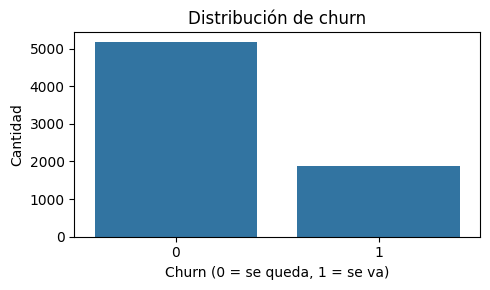

In [68]:
# -------------------------------
# Distribución de la variable objetivo
# -------------------------------
churn_rate = df[target_col].value_counts(normalize=True).sort_index()
display(pd.DataFrame({
    "proporción": churn_rate,
    "conteo": df[target_col].value_counts().sort_index()
}))

plt.figure(figsize=(5, 3))
ax = sns.countplot(x=target_col, data=df)
ax.set_title("Distribución de churn")
ax.set_xlabel("Churn (0 = se queda, 1 = se va)")
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.show()

In [69]:
# ================================
# Resumen variables numéricas
# ================================
summary_num = df[numeric_features].describe().T
summary_num = summary_num[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
display(summary_num)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [70]:
# ================================
# Resumen variables categóricas
# ================================
summary_cat = pd.concat(
    [
        df[c]
        .astype("object")
        .value_counts(dropna=False)
        .head(10)
        .rename_axis("categoría")
        .reset_index(name="conteo")
        .assign(variable=c)
        for c in categorical_features
    ],
    ignore_index=True
)

display(summary_cat[["variable", "categoría", "conteo"]].head(30))

,variable,categoría,conteo
0,gender,Male,3555
1,gender,Female,3488
2,SeniorCitizen,0,5901
3,SeniorCitizen,1,1142
4,Partner,No,3641
5,Partner,Yes,3402
6,Dependents,No,4933
7,Dependents,Yes,2110
8,PhoneService,Yes,6361
9,PhoneService,No,682


In [71]:
# ================================
# Faltantes antes de corrección de tipos
# ================================
missing_before = (
    df[numeric_features + categorical_features + [target_col]]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

display(
    pd.DataFrame({"% faltante (antes)": (100 * missing_before).round(2)})
    .query("`% faltante (antes)` > 0")
)

# ================================
# Corrección de tipo conocido
# ================================
# TotalCharges suele venir como string por espacios vacíos
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# ================================
# Faltantes después de corrección
# ================================
missing_after = (
    df[numeric_features + categorical_features + [target_col]]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

display(
    pd.DataFrame({"% faltante (después)": (100 * missing_after).round(2)})
    .query("`% faltante (después)` > 0")
)


,% faltante (antes)
TotalCharges,0.16


,% faltante (después)
TotalCharges,0.16


In [72]:
df.loc[df["TotalCharges"].isna(), "tenure"].describe()

count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64

La variable **TotalCharges** presenta un **0.16% de valores faltantes**.

El análisis muestra que **todos los registros con valores faltantes en `TotalCharges` corresponden a clientes con `tenure = 0`**, es decir, clientes recién incorporados que aún no han generado cargos acumulados.

Por lo tanto, estos casos no representan errores de datos, sino una situación consistente con la lógica del negocio. Aun así, se tratarán como **faltantes reales** y se manejarán mediante imputación dentro del pipeline de preprocesamiento.


In [73]:
# ================================
# Variable objetivo
# ================================
y = pd.to_numeric(df[target_col], errors="coerce")

# Mantener solo filas válidas en y
mask = y.notna()
df = df.loc[mask].copy()
y = y.loc[mask].astype(int)

# ================================
# Matriz de features
# ================================
X = df[numeric_features + categorical_features].copy()

# ================================
# Preprocesamiento numérico
# ================================
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ================================
# Preprocesamiento categórico
# ================================
categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# ================================
# ColumnTransformer base
# ================================
preprocessor_base = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_features),
        ("cat", categorical_preprocess, categorical_features)
    ],
    remainder="drop"
)

X.shape, y.shape


((7043, 19), (7043,))

In [80]:
df[target_col].value_counts(dropna=False).head(5)


Churn
0    5174
1    1869
Name: count, dtype: int64

In [81]:
df[target_col].head(10).tolist(), df[target_col].dtype

([0, 0, 1, 0, 1, 1, 0, 0, 1, 0], dtype('int64'))

## Paso 2 — Modelo base (sin polinomios) con k-fold estratificado

Se entrena una regresión logística sobre las *features* preprocesadas. Para evaluar desempeño fuera de muestra, se usa validación cruzada estratificada.

La métrica principal de análisis se complementa con ROC/AUC y Precision–Recall/PR-AUC, ya que el churn suele ser una clase minoritaria.

In [82]:
def crossval_full_report(pipeline, X, y, cv, positive_label=1):
    rows = []
    mean_fpr = np.linspace(0, 1, 200)
    tprs = []
    aucs = []

    mean_recall = np.linspace(0, 1, 200)
    precisions_interp = []
    aps = []

    y_true_all = []
    y_pred_all = []

    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        pipeline.fit(X_tr, y_tr)
        proba = pipeline.predict_proba(X_te)[:, 1]
        pred = (proba >= 0.5).astype(int)

        y_true_all.extend(y_te.tolist())
        y_pred_all.extend(pred.tolist())

        rows.append({
            "fold": fold,
            "accuracy": accuracy_score(y_te, pred),
            "precision": precision_score(y_te, pred, zero_division=0),
            "recall": recall_score(y_te, pred, zero_division=0),
            "f1": f1_score(y_te, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_te, proba),
            "pr_auc": average_precision_score(y_te, proba)
        })

        fpr, tpr, _ = roc_curve(y_te, proba)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0

        precision, recall, _ = precision_recall_curve(y_te, proba)
        ap = average_precision_score(y_te, proba)
        aps.append(ap)
        p_interp = np.interp(mean_recall, recall[::-1], precision[::-1])
        precisions_interp.append(p_interp)

    metrics_df = pd.DataFrame(rows)
    summary = metrics_df.drop(columns=["fold"]).agg(["mean", "std"]).T
    summary.columns = ["media", "desv"]

    cm = confusion_matrix(y_true_all, y_pred_all)

    roc_mean_tpr = np.mean(tprs, axis=0)
    roc_mean_tpr[-1] = 1.0
    roc_mean_auc = float(np.mean(aucs))
    roc_std_auc = float(np.std(aucs))

    pr_mean_precision = np.mean(precisions_interp, axis=0)
    pr_mean_ap = float(np.mean(aps))
    pr_std_ap = float(np.std(aps))

    artifacts = {
        "metrics_by_fold": metrics_df,
        "summary": summary,
        "cm": cm,
        "roc": {"mean_fpr": mean_fpr, "mean_tpr": roc_mean_tpr, "mean_auc": roc_mean_auc, "std_auc": roc_std_auc},
        "pr": {"mean_recall": mean_recall, "mean_precision": pr_mean_precision, "mean_ap": pr_mean_ap, "std_ap": pr_std_ap}
    }
    return artifacts

,media,desv
roc_auc,0.844847,0.014856
accuracy,0.804767,0.012112
precision,0.656124,0.024224
pr_auc,0.655866,0.028261
f1,0.600835,0.029198
recall,0.554283,0.032788


<Figure size 450x400 with 0 Axes>

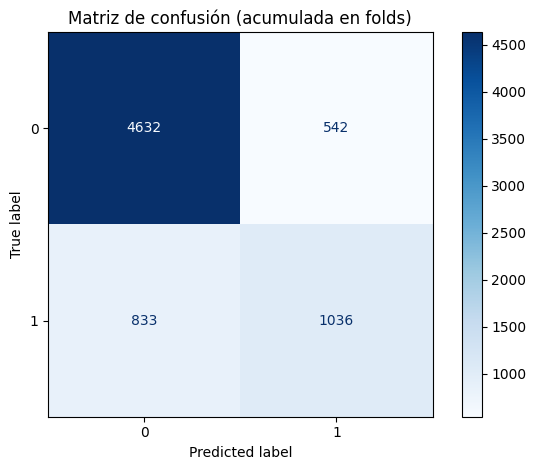

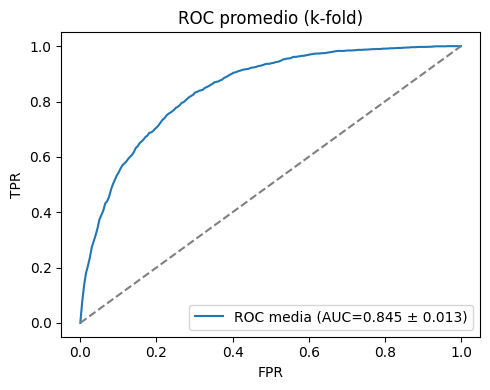

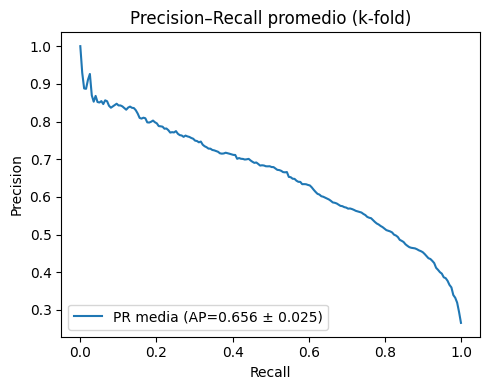

In [85]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg_base = Pipeline(steps=[
    ("preprocess", preprocessor_base),
    ("clf", LogisticRegression(penalty=None, solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE))
])

base_art = crossval_full_report(logreg_base, X, y, cv=cv)

display(base_art["summary"].sort_values("media", ascending=False))

plt.figure(figsize=(4.5, 4))
ConfusionMatrixDisplay(base_art["cm"], display_labels=[0, 1]).plot(values_format="d", cmap="Blues")
plt.title("Matriz de confusión (acumulada en folds)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.plot(base_art["roc"]["mean_fpr"], base_art["roc"]["mean_tpr"], label=f"ROC media (AUC={base_art['roc']['mean_auc']:.3f} ± {base_art['roc']['std_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC promedio (k-fold)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.plot(base_art["pr"]["mean_recall"], base_art["pr"]["mean_precision"], label=f"PR media (AP={base_art['pr']['mean_ap']:.3f} ± {base_art['pr']['std_ap']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall promedio (k-fold)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Evaluación del modelo base — Regresión Logística

Con validación cruzada estratificada (5 folds), el modelo muestra una buena capacidad para separar clientes que hacen churn de los que no.

- **ROC AUC:** 0.845 ± 0.015  
- **PR AUC (Average Precision):** 0.656 ± 0.025

Mirando la clasificación con umbral 0.5 (matriz de confusión acumulada en los folds), la lectura es más “operativa”:

- **Recall (churn):** 0.554  
- **Precision (churn):** 0.656  
- **F1:** 0.601

En otras palabras, el modelo recupera cerca del 55% de los churn reales; y cuando predice churn, acierta cerca del 66%. Se ve una cantidad importante de falsos negativos, lo que es típico cuando el umbral 0.5 no está ajustado al objetivo de negocio.

En esta actividad lo dejamos como línea base. Más adelante se prueba si agregar no linealidad (polinomios) aporta señal y si la regularización ayuda a controlar la complejidad cuando crece la cantidad de variables.

## Paso 3 — Regresión logística con transformaciones polinomiales

Se generan términos polinomiales de **grado 2** (incluyendo interacciones) solo sobre un subconjunto pequeño de variables numéricas, para aumentar expresividad sin disparar innecesariamente la dimensionalidad.

Se mantiene el mismo esquema de validación cruzada y se comparan métricas y curvas frente al modelo base.

In [22]:
# Selección de 3–5 numéricas para polinomios (dependiendo de disponibilidad real)
poly_numeric = [c for c in ["tenure", "MonthlyCharges", "TotalCharges"] if c in numeric_features][:5]
non_poly_numeric = [c for c in numeric_features if c not in poly_numeric]

poly_numeric, non_poly_numeric

(['tenure', 'MonthlyCharges', 'TotalCharges'], [])

,media,desv
roc_auc,0.845719,0.013064
accuracy,0.799231,0.009249
pr_auc,0.658775,0.018075
precision,0.649182,0.021896
f1,0.583332,0.020125
recall,0.529678,0.019840


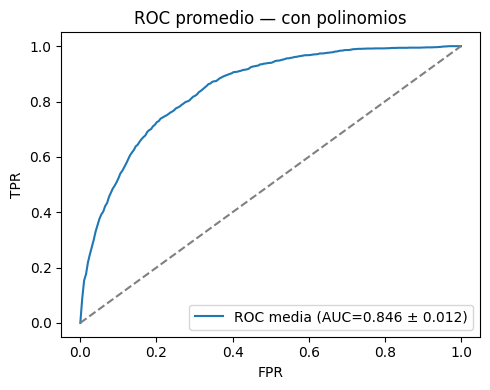

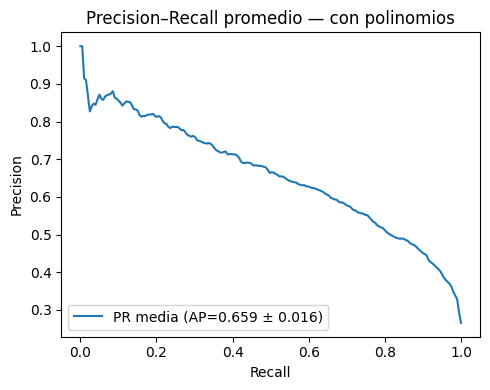

In [23]:
poly_numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

plain_numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ("poly_num", poly_numeric_preprocess, poly_numeric),
        ("num", plain_numeric_preprocess, non_poly_numeric),
        ("cat", categorical_preprocess, categorical_features)
    ],
    remainder="drop"
)

logreg_poly = Pipeline(steps=[
    ("preprocess", preprocessor_poly),
    ("clf", LogisticRegression(penalty=None, solver="lbfgs", max_iter=4000, random_state=RANDOM_STATE))
])

poly_art = crossval_full_report(logreg_poly, X, y, cv=cv)

display(poly_art["summary"].sort_values("media", ascending=False))

plt.figure(figsize=(5, 4))
plt.plot(poly_art["roc"]["mean_fpr"], poly_art["roc"]["mean_tpr"], label=f"ROC media (AUC={poly_art['roc']['mean_auc']:.3f} ± {poly_art['roc']['std_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC promedio — con polinomios")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.plot(poly_art["pr"]["mean_recall"], poly_art["pr"]["mean_precision"], label=f"PR media (AP={poly_art['pr']['mean_ap']:.3f} ± {poly_art['pr']['std_ap']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall promedio — con polinomios")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Resultados — Modelo base

Con 5-fold estratificado, el modelo base logra buena discriminación (AUC-ROC ~0.845) y un desempeño razonable en la clase churn (PR-AUC ~0.656).

Con umbral 0.5, el recall de churn es moderado (se escapan varios churn reales), mientras que la precisión es mayor (cuando predice churn, suele acertar). En la práctica, este tipo de modelo suele requerir ajuste de umbral según la capacidad del equipo de retención y el costo de los falsos negativos.

En los siguientes pasos se evalúa si los polinomios aportan señal y si la regularización ayuda a estabilizar el modelo cuando aumenta la dimensionalidad.

In [24]:
scorer_pr_auc = "average_precision"

grid_base = Pipeline(steps=[
    ("preprocess", preprocessor_poly),
    ("clf", LogisticRegression(max_iter=6000, random_state=RANDOM_STATE))
])

param_grid_l2 = {
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
    "clf__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
}

grid_l2 = GridSearchCV(
    estimator=grid_base,
    param_grid=param_grid_l2,
    scoring=scorer_pr_auc,
    cv=cv,
    n_jobs=-1
)

grid_l2.fit(X, y)

grid_l2.best_params_, grid_l2.best_score_

({'clf__C': 1.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'},
 np.float64(0.6593799979688225))

In [25]:
param_grid_l1 = {
    "clf__penalty": ["l1"],
    "clf__solver": ["liblinear"],
    "clf__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
}

grid_l1 = GridSearchCV(
    estimator=grid_base,
    param_grid=param_grid_l1,
    scoring=scorer_pr_auc,
    cv=cv,
    n_jobs=-1
)

grid_l1.fit(X, y)

grid_l1.best_params_, grid_l1.best_score_

({'clf__C': 3.0, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'},
 np.float64(0.6596520774731804))

In [26]:
best_l2 = grid_l2.best_estimator_
best_l1 = grid_l1.best_estimator_

l2_art = crossval_full_report(best_l2, X, y, cv=cv)
l1_art = crossval_full_report(best_l1, X, y, cv=cv)

print("Resumen L2")
display(l2_art["summary"].sort_values("media", ascending=False))

print("Resumen L1")
display(l1_art["summary"].sort_values("media", ascending=False))

Resumen L2


,media,desv
roc_auc,0.846018,0.013501
accuracy,0.800650,0.010130
pr_auc,0.659380,0.017986
precision,0.652636,0.023625
f1,0.586029,0.021993
recall,0.531819,0.021522


Resumen L1


,media,desv
roc_auc,0.846050,0.013408
accuracy,0.800934,0.010356
pr_auc,0.659652,0.017665
precision,0.652854,0.023805
f1,0.587094,0.022697
recall,0.533423,0.022409


In [27]:
def compact_compare_table(base_art, poly_art, l2_art, l1_art):
    rows = []
    for name, art in [("Base", base_art), ("Polinomios", poly_art), ("Polinomios + L2", l2_art), ("Polinomios + L1", l1_art)]:
        s = art["summary"]
        rows.append({
            "modelo": name,
            "accuracy (media)": s.loc["accuracy", "media"],
            "precision (media)": s.loc["precision", "media"],
            "recall (media)": s.loc["recall", "media"],
            "f1 (media)": s.loc["f1", "media"],
            "AUC-ROC (media)": s.loc["roc_auc", "media"],
            "PR-AUC (media)": s.loc["pr_auc", "media"]
        })
    out = pd.DataFrame(rows)
    num_cols = out.columns.drop("modelo")
    out[num_cols] = out[num_cols].astype(float)
    return out

compare_tbl = compact_compare_table(base_art, poly_art, l2_art, l1_art)
display(compare_tbl.sort_values("PR-AUC (media)", ascending=False))

,modelo,accuracy (media),precision (media),recall (media),f1 (media),AUC-ROC (media),PR-AUC (media)
3,Polinomios + L1,0.800934,0.652854,0.533423,0.587094,0.846050,0.659652
2,Polinomios + L2,0.800650,0.652636,0.531819,0.586029,0.846018,0.659380
1,Polinomios,0.799231,0.649182,0.529678,0.583332,0.845719,0.658775
0,Base,0.798236,0.640227,0.546255,0.589436,0.844178,0.653223


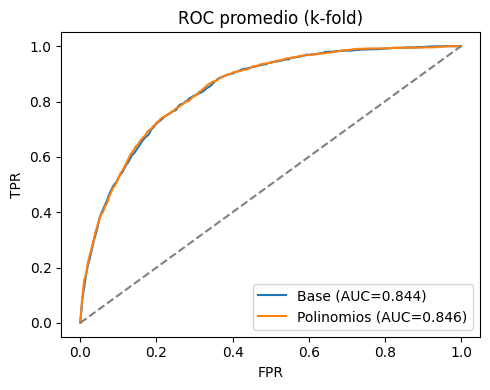

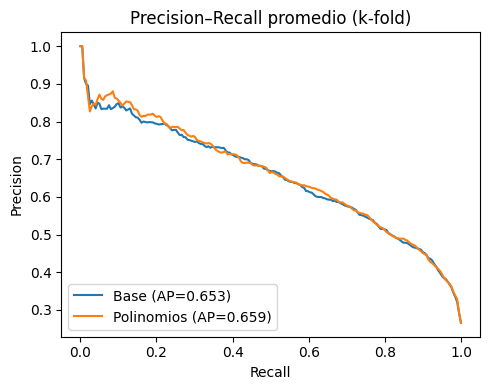

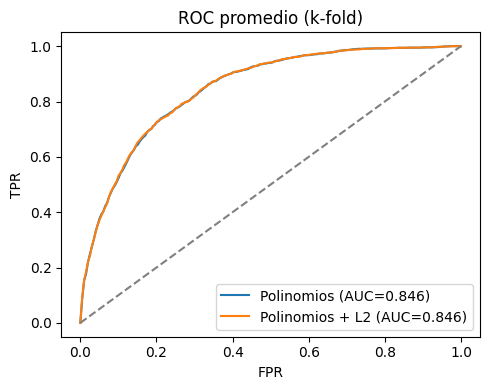

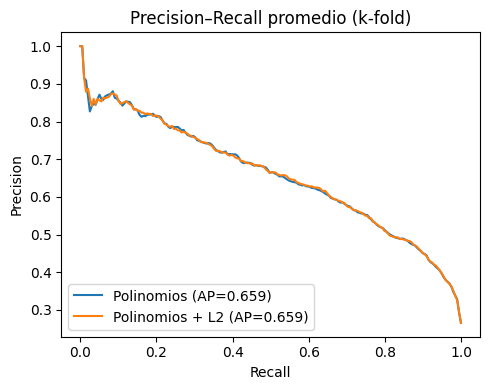

In [28]:
def plot_two_rocs(art_a, name_a, art_b, name_b):
    plt.figure(figsize=(5, 4))
    plt.plot(art_a["roc"]["mean_fpr"], art_a["roc"]["mean_tpr"], label=f"{name_a} (AUC={art_a['roc']['mean_auc']:.3f})")
    plt.plot(art_b["roc"]["mean_fpr"], art_b["roc"]["mean_tpr"], label=f"{name_b} (AUC={art_b['roc']['mean_auc']:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC promedio (k-fold)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_two_prs(art_a, name_a, art_b, name_b):
    plt.figure(figsize=(5, 4))
    plt.plot(art_a["pr"]["mean_recall"], art_a["pr"]["mean_precision"], label=f"{name_a} (AP={art_a['pr']['mean_ap']:.3f})")
    plt.plot(art_b["pr"]["mean_recall"], art_b["pr"]["mean_precision"], label=f"{name_b} (AP={art_b['pr']['mean_ap']:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall promedio (k-fold)")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

plot_two_rocs(base_art, "Base", poly_art, "Polinomios")
plot_two_prs(base_art, "Base", poly_art, "Polinomios")

plot_two_rocs(poly_art, "Polinomios", l2_art, "Polinomios + L2")
plot_two_prs(poly_art, "Polinomios", l2_art, "Polinomios + L2")

## Paso 5 — Análisis crítico y conclusiones

El churn suele ser una clase minoritaria. En ese escenario, **accuracy** puede dar una impresión de buen desempeño incluso si el modelo está fallando al detectar churn (falsos negativos). Por eso se analiza también la **matriz de confusión**, el **recall** de la clase positiva y la curva **Precision–Recall**, que es especialmente informativa con desbalance.

A continuación se discuten los resultados y se propone una selección de modelo considerando el objetivo de negocio: detectar clientes con alto riesgo de fuga, manteniendo una precisión razonable para no saturar acciones de retención.

### Respuestas (síntesis)

1. **Desbalance y accuracy:** si la mayoría no hace churn, un clasificador que casi siempre predice 0 puede lograr alta accuracy pero bajo recall en churn. La matriz de confusión lo evidencia (muchos falsos negativos implican clientes que se pierden sin accionar).

2. **Modelo recomendado:** en un problema de retención suele ser preferible priorizar un buen desempeño en la clase positiva. Por eso se considera **PR-AUC** y **F1** como criterios principales, complementados con AUC-ROC. De la tabla comparativa se elige el modelo con mejor PR-AUC (y F1 competitivo) y curvas estables.

3. **Efecto de polinomios:** pueden capturar no linealidades e interacciones, pero aumentan dimensionalidad y riesgo de sobreajuste. Si PR-AUC sube y se mantiene estable entre folds, aportan; si no, añaden complejidad sin beneficio.

4. **Efecto de regularización:** normalmente estabiliza los resultados entre folds y reduce magnitud de coeficientes. L1 además tiende a dejar un subconjunto de coeficientes en cero, simplificando el modelo.

5. **Trade-off precision/recall:** aumentar recall reduce falsos negativos (más clientes en riesgo detectados) pero suele reducir precision (más falsos positivos). La curva PR permite elegir un umbral operativo según capacidad del equipo de retención.

6. **Mejoras posibles:** calibración de probabilidades, ajuste de umbral, `class_weight='balanced'`, modelos no lineales (árboles/boosting), ingeniería de variables, y técnicas específicas para desbalance (por ejemplo, re-muestreo).